# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [2]:
# Import essential libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Load the dataset.

In [4]:
# Load and unzip the dataset
with zipfile.ZipFile('data.zip', 'r') as z:
    z.extractall('data')

print('Dataset extracted successfully')

# Set the dataset path
dataset_path = 'data/data'
print('Classes found:', os.listdir(dataset_path))

Dataset extracted successfully
Classes found: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [5]:
# Create a function to load the raw images
def load_image(filepath, target_size=(64, 64)):
    img = Image.open(filepath).convert('RGB')   # open and ensure 3 channels
    img = img.resize(target_size)               # resize to fixed size
    img = np.array(img) / 255.0                 # normalise to [0, 1]
    return img

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [6]:
# Get the images and their labels
images = []
labels = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        try:
            img = load_image(fpath)
            images.append(img)
            labels.append(class_name)
        except:
            pass   # skip corrupted files

# Convert to numpy arrays
X = np.array(images, dtype=np.float32)
y = np.array(labels)

print(f'Total images loaded : {len(X)}')
print(f'Image shape         : {X.shape}')
print(f'Unique classes      : {np.unique(y)}')

Total images loaded : 7625
Image shape         : (7625, 64, 64, 3)
Unique classes      : ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

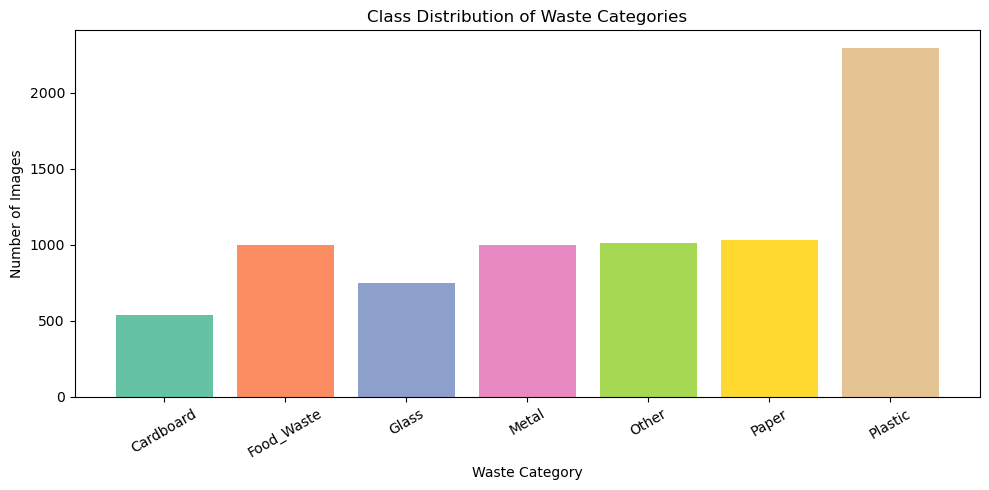

  Cardboard: 540
  Food_Waste: 1000
  Glass: 750
  Metal: 1000
  Other: 1010
  Paper: 1030
  Plastic: 2295


In [7]:
# Visualise Data Distribution
class_names, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color=sns.color_palette('Set2', len(class_names)))
plt.title('Class Distribution of Waste Categories')
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

for cls, cnt in zip(class_names, counts):
    print(f'  {cls}: {cnt}')

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

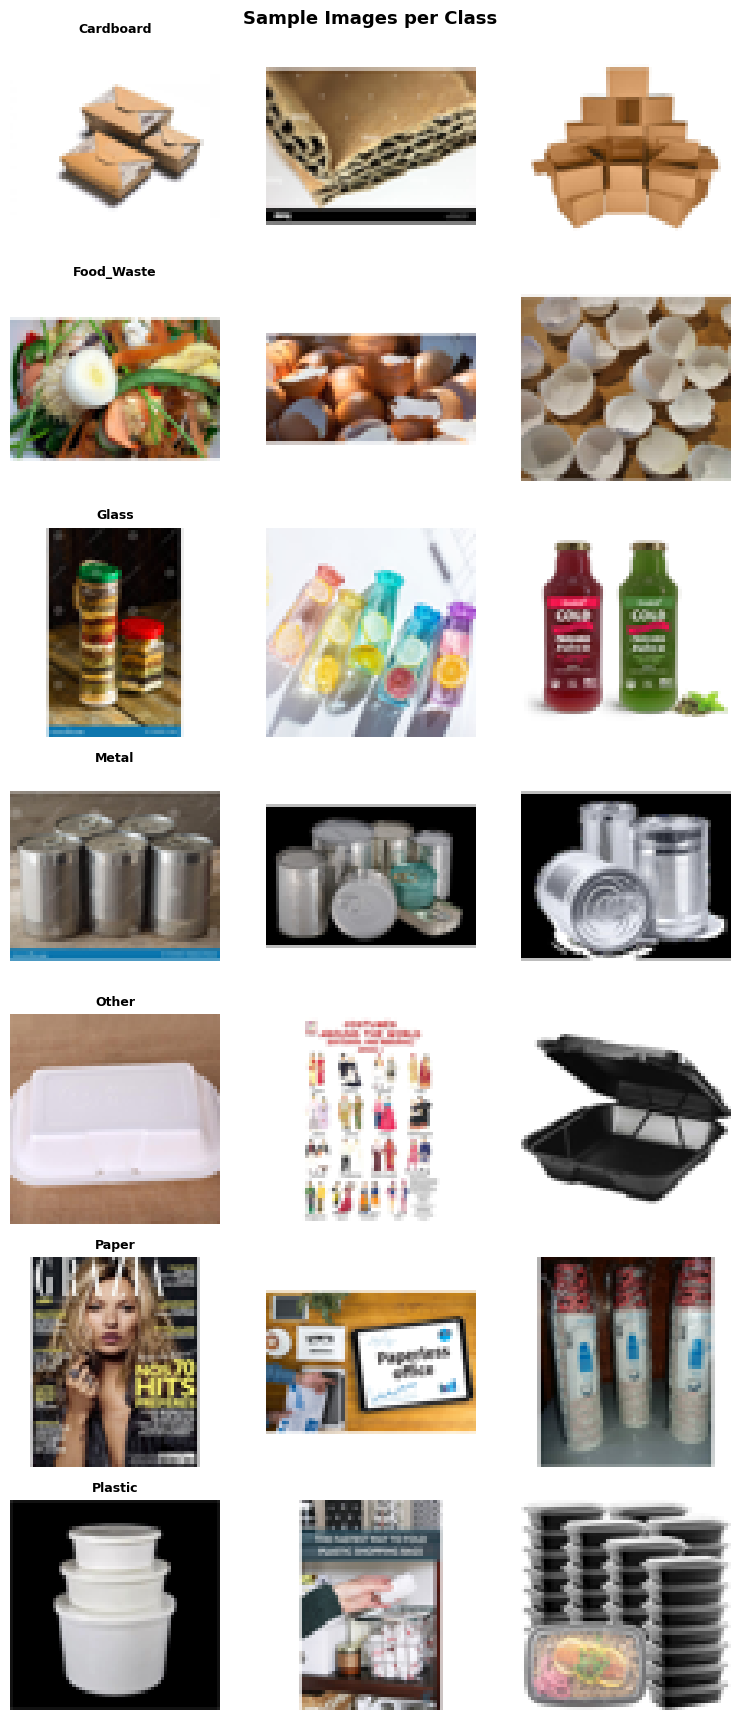

In [8]:
# Visualise Sample Images (across different labels)
fig, axes = plt.subplots(len(class_names), 3, figsize=(8, len(class_names) * 2.5))
fig.suptitle('Sample Images per Class', fontsize=13, fontweight='bold')

for row, cls in enumerate(class_names):
    class_indices = np.where(y == cls)[0]
    samples = np.random.choice(class_indices, 3, replace=False)
    for col, idx in enumerate(samples):
        axes[row][col].imshow(X[idx])
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [9]:
# Find the smallest and largest image dimensions from the data set
raw_sizes = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        try:
            img = Image.open(fpath)
            raw_sizes.append(img.size)   # (width, height)
        except:
            pass

widths  = [s[0] for s in raw_sizes]
heights = [s[1] for s in raw_sizes]

print(f'Smallest width  : {min(widths)}  |  Largest width  : {max(widths)}')
print(f'Smallest height : {min(heights)}  |  Largest height : {max(heights)}')

Smallest width  : 256  |  Largest width  : 256
Smallest height : 256  |  Largest height : 256


In [10]:
# Resize the image dimensions
# Images vary widely in size, so we resize all to 64x64.
# This is a good balance between speed and retaining enough detail for classification.
TARGET_SIZE = (64, 64)

images_resized = []
for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        try:
            img = load_image(fpath, target_size=TARGET_SIZE)
            images_resized.append(img)
        except:
            pass

X = np.array(images_resized, dtype=np.float32)
print(f'Resized dataset shape: {X.shape}')   # (N, 64, 64, 3)

Resized dataset shape: (7625, 64, 64, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [11]:
# Encode the labels suitably
le = LabelEncoder()
y_encoded = le.fit_transform(y)                        # integer encode: 0-6
y_ohe     = to_categorical(y_encoded, num_classes=7)   # one-hot encode

print('Label encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

print(f'\ny_ohe shape: {y_ohe.shape}')

Label encoding mapping:
  0 -> Cardboard
  1 -> Food_Waste
  2 -> Glass
  3 -> Metal
  4 -> Other
  5 -> Paper
  6 -> Plastic

y_ohe shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [12]:
# Assign specified parts of the dataset to train and validation sets
# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_ohe, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f'Training set   : {X_train.shape[0]} images')
print(f'Validation set : {X_val.shape[0]} images')
print(f'Test set       : {X_test.shape[0]} images')

Training set   : 5337 images
Validation set : 1144 images
Test set       : 1144 images


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [13]:
# Build and compile the model
# Configuration 1: Baseline — simple and fast
model = models.Sequential([
    # Conv block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Conv block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Conv block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Fully connected head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')   # 7 waste categories
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,847 (4.87 MB)

 Trainable params: 1,275,399 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 411ms/step - accuracy: 0.3429 - loss: 2.1121 - val_accuracy: 0.1241 - val_loss: 2.5419 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 376ms/step - accuracy: 0.4431 - loss: 1.4924 - val_accuracy: 0.2928 - val_loss: 2.6345 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 398ms/step - accuracy: 0.4917 - loss: 1.3564 - val_accuracy: 0.1827 - val_loss: 3.1508 - learning_rate: 0.0010
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 397ms/step - accuracy: 0.5511 - loss: 1.2223 - val_accuracy: 0.3068 - val_loss: 2.2540 - learning_rate: 0.0010
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 392ms/step - accuracy: 0.6058 - loss: 1.0937 - val_accuracy: 0.3636 - val_loss: 2.1572 - learning_rate: 0.0010
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 397ms/step - accuracy: 0.6504 - loss: 0.9643 - val_accuracy: 0.4878 - val_loss: 1.4620 - learning_rate: 0.0010
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 395ms/step - accuracy: 0.6817 - loss: 0.

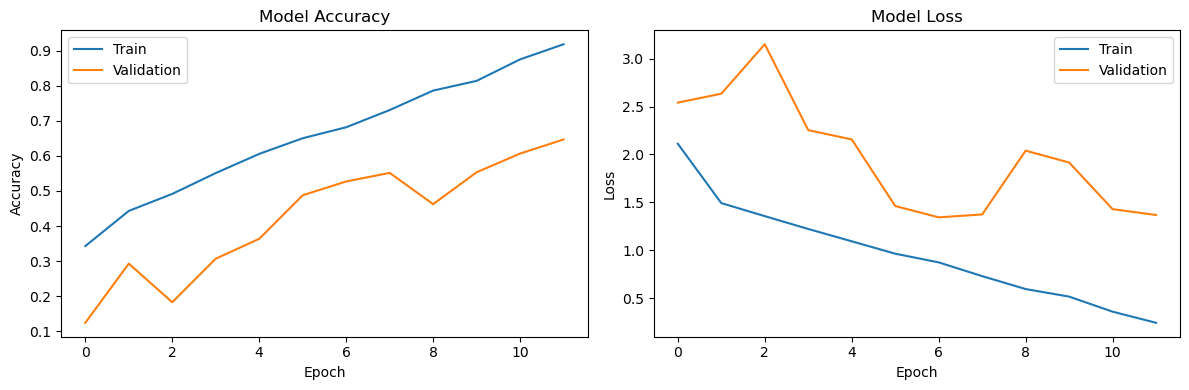

In [14]:
# Training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Accuracy : 0.5437
Test Loss     : 1.3211
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.62      0.69      0.65        70
  Food_Waste       0.55      0.51      0.53       139
       Glass       0.74      0.32      0.44       132
       Metal       0.53      0.42      0.46       159
       Other       0.36      0.34      0.35       129
       Paper       0.59      0.43      0.50       157
     Plastic       0.55      0.79      0.65       358

    accuracy                           0.54      1144
   macro avg       0.56      0.50      0.51      1144
weighted avg       0.56      0.54      0.53      1144



<Figure size 800x600 with 0 Axes>

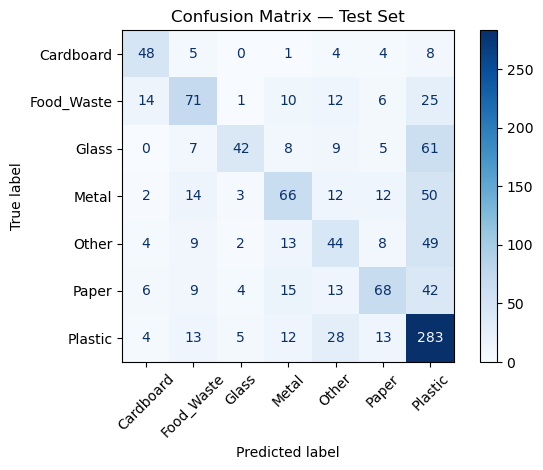

In [15]:
# Evaluate on the test set; display suitable metrics
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

# Predictions
y_pred     = model.predict(X_test)
y_pred_cls = np.argmax(y_pred,  axis=1)
y_true_cls = np.argmax(y_test,  axis=1)

# Classification report
print('\nClassification Report:')
print(classification_report(y_true_cls, y_pred_cls, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [16]:
# Define augmentation steps to augment images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [17]:
# Create a function to augment the images
def get_augmented_sample(images, labels, aug_gen, n_samples):
    """Generate n_samples augmented images from the given set."""
    aug_images, aug_labels = [], []
    for x_batch, y_batch in aug_gen.flow(images, labels, batch_size=n_samples, seed=42):
        aug_images.append(x_batch)
        aug_labels.append(y_batch)
        break   # one batch is enough
    return np.concatenate(aug_images), np.concatenate(aug_labels)

In [18]:
# Create the augmented training dataset
X_aug, y_aug = get_augmented_sample(X_train, y_train, aug, n_samples=len(X_train))

# Combine original and augmented samples
X_train_aug = np.concatenate([X_train, X_aug])
y_train_aug = np.concatenate([y_train, y_aug])

print(f'Original training size : {len(X_train)}')
print(f'Augmented training size: {len(X_train_aug)}')

Original training size : 5337
Augmented training size: 10674


##### **4.1.2**

Train the model on the new augmented dataset.

In [19]:
# Train the model using augmented images
model_aug = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')
])

model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks
)

aug_loss, aug_acc = model_aug.evaluate(X_test, y_test, verbose=0)
print(f'\nAugmented Model — Test Accuracy: {aug_acc:.4f}')
print(f'Augmented Model — Test Loss    : {aug_loss:.4f}')

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 76s 392ms/step - accuracy: 0.3453 - loss: 1.8853 - val_accuracy: 0.2885 - val_loss: 4.2434 - learning_rate: 0.0010
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 67s 398ms/step - accuracy: 0.4192 - loss: 1.5165 - val_accuracy: 0.2762 - val_loss: 2.4162 - learning_rate: 0.0010
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.4735 - loss: 1.3940
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
167/167 ━━━━━━━━━━━━━━━━━━━━ 65s 388ms/step - accuracy: 0.4765 - loss: 1.3972 - val_accuracy: 0.3523 - val_loss: 1.8899 - learning_rate: 0.0010
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 64s 382ms/step - accuracy: 0.5543 - loss: 1.1885 - val_accuracy: 0.5367 - val_loss: 1.3385 - learning_rate: 5.0000e-04
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 62s 373ms/step - accuracy: 0.6028 - loss: 1.0636 - val_accuracy: 0.5490 - val_loss: 1.2873 - learning_rate: 5.0000e-04
Epoch 6/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 66s 397ms/step - accurac

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

### 1. Data Findings

**Dataset overview.** The dataset contains 7,625 images across 7 waste categories: Cardboard, Food_Waste, Glass, Metal, Other, Paper, and Plastic. Each category is stored in its own folder, and images were loaded and normalised to the [0, 1] range.

**Class distribution.** The dataset is significantly imbalanced. Plastic is the dominant class with 2,295 images, while Cardboard is the smallest with only 540 images; a ratio of over 4:1. Other classes (Food_Waste, Metal, Other, Paper) each have around 1,000 images. This imbalance biases the model towards predicting Plastic more often.

**Image dimensions.** All raw images were already a uniform 256×256 pixels. They were resized to 64×64 for faster training while retaining enough spatial detail for classification.

**Visual observations.** Sample images showed high intra-class variability for example, Food_Waste includes coffee grounds, fruit peels, and tea bags. Some classes like Glass and Metal share reflective surface appearances, making them harder to separate.

---

### 2. Model Training Results

A CNN with 3 convolutional layers (32 → 64 → 128 filters) was trained with the following setup:
- BatchNormalization after each convolution layer for stable training
- Dropout (0.4) to reduce overfitting
- Adam optimiser with categorical crossentropy loss
- EarlyStopping (patience=5) and ReduceLROnPlateau (patience=3) callbacks

**Results summary:**

| Model | Test Accuracy | Test Loss |
|---|---|---|
| Baseline CNN | 0.5437 | 1.3211 |
| CNN + Augmentation | 0.6075 | 1.1300 |

**Key observations:**
- The baseline model trained for 12 epochs before EarlyStopping triggered. Training accuracy reached 91% but test accuracy was only 54%, indicating significant overfitting.
- The augmented model trained for 11 epochs and achieved 60.75% test accuracy which is a 6.4 percentage point improvement over the baseline, showing that augmentation helped generalisation.
- **Glass** had the worst recall (0.32). Only 42 out of 132 Glass images were classified correctly. Most Glass images were likely misclassified as Plastic due to the dominance of that class.
- **Metal, Other, and Paper** also performed poorly with recalls of 0.42, 0.34, and 0.43 respectively.
- **Plastic** had the highest recall (0.79) and **Cardboard** had the highest precision (0.62), both benefiting from either large sample size or visual distinctiveness.
- The overall macro F1-score of 0.51 reflects the model struggling with minority and visually similar classes.

---

### 3. Assumptions
- All images are correctly labelled as per their folder names.
- A 64×64 target size was chosen as a trade-off between training speed and detail retention.
- A 70/15/15 train/validation/test split was used with stratification to preserve class proportions.

---

### 4. Future Improvements
- The large gap between training accuracy (~91%) and test accuracy (~54%) in the baseline model suggests overfitting. Stronger regularisation or more dropout layers would help.
- Using a larger image size (e.g. 128×128) may recover detail lost during downscaling, particularly for Glass and Metal.
- Transfer learning with a pretrained model like MobileNetV2 could push accuracy well above 80%.
- Class-weighted loss or targeted oversampling for Cardboard specifically would help reduce the bias towards Plastic.